# Runs aral sea model using PCR input

In [10]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr

import importlib
import src.aral as aral
importlib.reload(aral)
from src.constants import STATIONS_PCR

from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data


In [11]:
folder_path = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs")

nc_files = sorted(folder_path.rglob("discharge_dailyTot_output.nc"))
if not nc_files:
    raise FileNotFoundError(f"No discharge_dailyTot_output.nc files found under {folder_path}")

print(f"Found {len(nc_files)} files:")
for f in nc_files:
    print(f)



Found 3 files:
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs/run_1940_1970/netcdf/discharge_dailyTot_output.nc
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs/run_1965_1995/netcdf/discharge_dailyTot_output.nc
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs/run_1990_2020/netcdf/discharge_dailyTot_output.nc


In [12]:
folder_path_no_agri = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs_no_agri")

nc_files_no_agri = sorted(folder_path_no_agri.rglob("discharge_dailyTot_output.nc"))
if not nc_files_no_agri:
    raise FileNotFoundError(f"No discharge_dailyTot_output.nc files found under {folder_path_no_agri}")

print(f"Found {len(nc_files_no_agri)} files:")
for f in nc_files_no_agri:
    print(f)



Found 3 files:
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs_no_agri/run_1940_1970/netcdf/discharge_dailyTot_output.nc
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs_no_agri/run_1965_1995/netcdf/discharge_dailyTot_output.nc
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/era5_parallel_runs_no_agri/run_1990_2020/netcdf/discharge_dailyTot_output.nc


In [13]:
folder_path_cmip = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/cmip_parallel_runs")

In [14]:
# Load CMIP files
nc_files_cmip = sorted(folder_path_cmip.rglob("discharge_dailyTot_output.nc"))
if not nc_files_cmip:
    raise FileNotFoundError(f"No discharge_dailyTot_output.nc files found under {folder_path_cmip}")

print(f"Found {len(nc_files_cmip)} CMIP files:")
for f in nc_files_cmip:
    print(f)

Found 1 CMIP files:
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/long_runs_pcr/cmip_parallel_runs/run_2020_2030/netcdf/discharge_dailyTot_output.nc


In [6]:
# Inspect each file time coverage (no global combine)
file_summaries = []
for fp in nc_files:
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        file_summaries.append(
            {
                "run": fp.parent.parent.name,
                "file": str(fp),
                "start": pd.to_datetime(ds["time"].values[0]),
                "end": pd.to_datetime(ds["time"].values[-1]),
                "n_time": ds.sizes["time"],
            }
        )

summary_df = pd.DataFrame(file_summaries).sort_values("start").reset_index(drop=True)
print(summary_df)

             run                                               file  \
0  run_1940_1970  /home/avandervee3/MSc_AralSea/book/thesis_proj...   
1  run_1965_1995  /home/avandervee3/MSc_AralSea/book/thesis_proj...   
2  run_1990_2020  /home/avandervee3/MSc_AralSea/book/thesis_proj...   

       start        end  n_time  
0 1940-01-01 1970-12-31   11323  
1 1965-01-01 1995-12-31   11322  
2 1990-01-01 2020-12-31   11323  


In [7]:
# Inspect each CMIP file time coverage
file_summaries_cmip = []
for fp in nc_files_cmip:
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        file_summaries_cmip.append(
            {
                "run": fp.parent.parent.name,
                "file": str(fp),
                "start": pd.to_datetime(ds["time"].values[0]),
                "end": pd.to_datetime(ds["time"].values[-1]),
                "n_time": ds.sizes["time"],
            }
        )

summary_df_cmip = pd.DataFrame(file_summaries_cmip).sort_values("start").reset_index(drop=True)
print(summary_df_cmip)

             run                                               file  \
0  run_2020_2030  /home/avandervee3/MSc_AralSea/book/thesis_proj...   

       start        end  n_time  
0 2020-01-01 2030-12-31    4018  


In [8]:
# Inspect each file time coverage (no global combine)
file_summaries_no_agri = []
for fp in nc_files_no_agri:
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        file_summaries_no_agri.append(
            {
                "run": fp.parent.parent.name,
                "file": str(fp),
                "start": pd.to_datetime(ds["time"].values[0]),
                "end": pd.to_datetime(ds["time"].values[-1]),
                "n_time": ds.sizes["time"],
            }
        )

summary_df_no_agri = pd.DataFrame(file_summaries_no_agri).sort_values("start").reset_index(drop=True)
print(summary_df_no_agri)

             run                                               file  \
0  run_1940_1970  /home/avandervee3/MSc_AralSea/book/thesis_proj...   
1  run_1965_1995  /home/avandervee3/MSc_AralSea/book/thesis_proj...   
2  run_1990_2020  /home/avandervee3/MSc_AralSea/book/thesis_proj...   

       start        end  n_time  
0 1940-01-01 1970-12-31   11323  
1 1965-01-01 1995-12-31   11322  
2 1990-01-01 2020-12-31   11323  


In [9]:
# Extract discharge at station locations for each file separately
dfs_by_run = {}
for fp in nc_files:
    run_name = fp.parent.parent.name
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        ts_dict = {}
        for name, coords in STATIONS_PCR.items():
            ts = ds["discharge"].sel(
                lat=coords["lat"],
                lon=coords["lon"],
                method="nearest",
            ).load()
            ts_dict[name] = ts.values

        df_run = pd.DataFrame(ts_dict, index=pd.to_datetime(ds["time"].values))
        df_run.index.name = "Time"
        dfs_by_run[run_name] = df_run
        print(f"{run_name}: shape={df_run.shape}, period={df_run.index.min()} -> {df_run.index.max()}")

# Keep one run in `df` for downstream cells
selected_run = sorted(dfs_by_run.keys())[-1]
df = dfs_by_run[selected_run]
print(f"\nUsing run '{selected_run}' as df for downstream cells.")
print(df.tail())

run_1940_1970: shape=(11323, 6), period=1940-01-01 00:00:00 -> 1970-12-31 00:00:00
run_1965_1995: shape=(11322, 6), period=1965-01-01 00:00:00 -> 1995-12-31 00:00:00
run_1990_2020: shape=(11323, 6), period=1990-01-01 00:00:00 -> 2020-12-31 00:00:00

Using run 'run_1990_2020' as df for downstream cells.
               Chatly   Kazalinsk       Kerki  Tyumen-Aryk  Uch-Kurgan  \
Time                                                                     
2020-12-27  38.308277  356.275452  190.196106   264.137878   64.407326   
2020-12-28  32.501701  334.661865  167.209763   255.408630   64.907631   
2020-12-29  23.162603  316.878510  187.423141   244.750137   63.910439   
2020-12-30  14.966064  305.970428  170.542282   239.609161   64.197197   
2020-12-31  14.079966  296.778625  180.978775   218.755188   61.850208   

                Garm  
Time                  
2020-12-27  5.020274  
2020-12-28  4.453152  
2020-12-29  4.963498  
2020-12-30  4.349715  
2020-12-31  4.899023  


In [10]:
# Extract discharge at station locations for each CMIP file separately
dfs_by_run_cmip = {}
for fp in nc_files_cmip:
    run_name = fp.parent.parent.name
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        ts_dict = {}
        for name, coords in STATIONS_PCR.items():
            ts = ds["discharge"].sel(
                lat=coords["lat"],
                lon=coords["lon"],
                method="nearest",
            ).load()
            ts_dict[name] = ts.values

        df_run = pd.DataFrame(ts_dict, index=pd.to_datetime(ds["time"].values))
        df_run.index.name = "Time"
        dfs_by_run_cmip[run_name] = df_run
        print(f"{run_name}: shape={df_run.shape}, period={df_run.index.min()} -> {df_run.index.max()}")

# Keep one run in `df_cmip` for downstream cells
selected_run_cmip = sorted(dfs_by_run_cmip.keys())[-1]
df_cmip = dfs_by_run_cmip[selected_run_cmip]
print(f"\nUsing run '{selected_run_cmip}' as df_cmip for downstream cells.")
print(df_cmip.tail())

run_2020_2030: shape=(4018, 6), period=2020-01-01 00:00:00 -> 2030-12-31 00:00:00

Using run 'run_2020_2030' as df_cmip for downstream cells.
              Chatly   Kazalinsk      Kerki  Tyumen-Aryk  Uch-Kurgan      Garm
Time                                                                          
2030-12-27  0.664931  215.510086  32.318790   245.076157   62.199299  4.335289
2030-12-28  0.507234  261.819519  19.027243   253.719910   66.909744  3.510035
2030-12-29  0.342292  272.287720  20.168421   265.447968   65.002266  4.040463
2030-12-30  0.198530  288.334778  27.623001   247.935471   61.644909  3.464225
2030-12-31  0.222442  277.072327  18.945250   249.927780   61.199108  3.916921


In [11]:
# Extract discharge at station locations for each file separately
dfs_by_run_no_agri = {}
for fp in nc_files_no_agri:
    run_name = fp.parent.parent.name
    with xr.open_dataset(fp, engine="netcdf4") as ds:
        ts_dict = {}
        for name, coords in STATIONS_PCR.items():
            ts = ds["discharge"].sel(
                lat=coords["lat"],
                lon=coords["lon"],
                method="nearest",
            ).load()
            ts_dict[name] = ts.values

        df_run = pd.DataFrame(ts_dict, index=pd.to_datetime(ds["time"].values))
        df_run.index.name = "Time"
        dfs_by_run_no_agri[run_name] = df_run
        print(f"{run_name}: shape={df_run.shape}, period={df_run.index.min()} -> {df_run.index.max()}")

# Keep one run in `df` for downstream cells
selected_run_no_agri = sorted(dfs_by_run_no_agri.keys())[-1]
df_no_agri = dfs_by_run_no_agri[selected_run_no_agri]
print(f"\nUsing run '{selected_run_no_agri}' as df for downstream cells.")
print(df_no_agri.tail())

run_1940_1970: shape=(11323, 6), period=1940-01-01 00:00:00 -> 1970-12-31 00:00:00
run_1965_1995: shape=(11322, 6), period=1965-01-01 00:00:00 -> 1995-12-31 00:00:00
run_1990_2020: shape=(11323, 6), period=1990-01-01 00:00:00 -> 2020-12-31 00:00:00

Using run 'run_1990_2020' as df for downstream cells.
                Chatly   Kazalinsk       Kerki  Tyumen-Aryk  Uch-Kurgan  \
Time                                                                      
2020-12-27  489.371704  500.061615  309.753967   416.846497   49.569206   
2020-12-28  492.884064  498.146912  320.684662   409.340424   48.878994   
2020-12-29  502.224121  495.128937  316.260651   400.311768   51.214836   
2020-12-30  504.580566  487.842255  297.339569   399.613922   47.977970   
2020-12-31  507.688995  488.159912  290.861633   401.181122   47.503456   

                Garm  
Time                  
2020-12-27  5.373839  
2020-12-28  4.860760  
2020-12-29  5.323270  
2020-12-30  4.748536  
2020-12-31  5.255394  


In [8]:
from collections import OrderedDict


def load_station_discharge_runs(nc_files, stations=STATIONS_PCR, engine="netcdf4"):
    """Load one discharge DataFrame per run with all stations extracted in a single xarray selection."""
    station_names = list(stations)
    station_lats = xr.DataArray(
        [stations[name]["lat"] for name in station_names],
        dims="station",
        coords={"station": station_names},
    )
    station_lons = xr.DataArray(
        [stations[name]["lon"] for name in station_names],
        dims="station",
        coords={"station": station_names},
    )

    dfs_by_run = OrderedDict()
    summaries = []

    for fp in nc_files:
        run_name = fp.parent.parent.name
        with xr.open_dataset(fp, engine=engine) as ds:
            discharge = ds["discharge"].sel(lat=station_lats, lon=station_lons, method="nearest")
            df_run = discharge.to_pandas()
            df_run.index = pd.to_datetime(df_run.index)
            df_run.index.name = "Time"
            df_run = df_run.reindex(columns=station_names)
            dfs_by_run[run_name] = df_run
            summaries.append(
                {
                    "run": run_name,
                    "file": str(fp),
                    "start": df_run.index.min(),
                    "end": df_run.index.max(),
                    "n_time": len(df_run),
                }
            )

    summary_df = pd.DataFrame(summaries).sort_values("start").reset_index(drop=True)
    return dfs_by_run, summary_df


# Optional one-line usage for the current ERA5/PCR runs:
# dfs_by_run, summary_df = load_station_discharge_runs(nc_files)
# dfs_by_run_no_agri, summary_df_no_agri = load_station_discharge_runs(nc_files_no_agri)
# dfs_by_run_cmip, summary_df_cmip = load_station_discharge_runs(nc_files_cmip)


In [15]:
import pickle
import re
from collections import OrderedDict
from concurrent.futures import ThreadPoolExecutor


# Define simulation roots once; add new simulations here later.
SIMULATION_ROOTS = {
    "era5_default": folder_path,
    "era5_no_agri": folder_path_no_agri,
    "cmip_default": folder_path_cmip,
}


def _infer_start_end_from_name_or_data(run_name, df_run):
    match = re.search(r"(\d{4})_(\d{4})", run_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    # Fallback for arbitrary names
    idx = pd.to_datetime(df_run.index)
    return int(idx.min().year), int(idx.max().year)


def _extract_run_df(fp, station_names, station_lats, station_lons, engine="netcdf4"):
    run_name = fp.parent.parent.name
    with xr.open_dataset(fp, engine=engine) as ds:
        discharge = ds["discharge"].sel(lat=station_lats, lon=station_lons, method="nearest")
        df_run = discharge.to_pandas()

    df_run.index = pd.to_datetime(df_run.index)
    df_run.index.name = "Time"
    df_run = df_run.reindex(columns=station_names)

    summary = {
        "run": run_name,
        "file": str(fp),
        "start": df_run.index.min(),
        "end": df_run.index.max(),
        "n_time": len(df_run),
    }
    return run_name, df_run, summary


def load_and_merge_simulation(
    sim_root,
    stations=STATIONS_PCR,
    engine="netcdf4",
    pattern="discharge_dailyTot_output.nc",
    n_workers=4,
):
    """Load all run-parts in one simulation, extract station discharge, and merge without overlaps."""
    nc_files = sorted(Path(sim_root).rglob(pattern))
    if not nc_files:
        raise FileNotFoundError(f"No {pattern} files found under {sim_root}")

    station_names = list(stations)
    station_lats = xr.DataArray(
        [stations[name]["lat"] for name in station_names],
        dims="station",
        coords={"station": station_names},
    )
    station_lons = xr.DataArray(
        [stations[name]["lon"] for name in station_names],
        dims="station",
        coords={"station": station_names},
    )

    if n_workers and n_workers > 1:
        with ThreadPoolExecutor(max_workers=n_workers) as pool:
            extracted = list(
                pool.map(
                    lambda fp: _extract_run_df(
                        fp=fp,
                        station_names=station_names,
                        station_lats=station_lats,
                        station_lons=station_lons,
                        engine=engine,
                    ),
                    nc_files,
                )
            )
    else:
        extracted = [
            _extract_run_df(
                fp=fp,
                station_names=station_names,
                station_lats=station_lats,
                station_lons=station_lons,
                engine=engine,
            )
            for fp in nc_files
        ]

    dfs_by_run = OrderedDict((run_name, df_run) for run_name, df_run, _ in extracted)
    summary_df = pd.DataFrame([summary for _, _, summary in extracted]).sort_values("start").reset_index(drop=True)

    ordering = []
    for run_name, df_run in dfs_by_run.items():
        start_year, end_year = _infer_start_end_from_name_or_data(run_name, df_run)
        ordering.append((start_year, end_year, run_name))
    ordering.sort(key=lambda row: (row[0], row[1]))

    periods_by_run = OrderedDict()
    for idx, (start_year, _end_year, run_name) in enumerate(ordering):
        start = f"{start_year}-01-01"
        if idx + 1 < len(ordering):
            end = f"{ordering[idx + 1][0] - 1}-12-31"
        else:
            end = str(dfs_by_run[run_name].index.max().date())
        periods_by_run[run_name] = (start, end)

    merged_parts = [dfs_by_run[run].loc[start:end] for run, (start, end) in periods_by_run.items()]
    df_merged = pd.concat(merged_parts).sort_index()
    df_merged = df_merged[~df_merged.index.duplicated(keep="last")]

    return {
        "dfs_by_run": dfs_by_run,
        "summary_df": summary_df,
        "periods_by_run": periods_by_run,
        "df": df_merged,
    }


def build_all_simulations(simulation_roots, cache_dir=None, use_cache=True, n_workers=4):
    """Build merged station DataFrames for multiple simulations with optional pickle cache."""
    cache_dir = Path(cache_dir) if cache_dir else None
    if cache_dir is not None:
        cache_dir.mkdir(parents=True, exist_ok=True)

    results = {}
    for sim_name, sim_root in simulation_roots.items():
        cache_file = cache_dir / f"{sim_name}_station_discharge.pkl" if cache_dir else None

        if use_cache and cache_file and cache_file.exists():
            with cache_file.open("rb") as f:
                payload = pickle.load(f)
        else:
            payload = load_and_merge_simulation(sim_root=sim_root, n_workers=n_workers)
            if cache_file:
                with cache_file.open("wb") as f:
                    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

        results[sim_name] = payload

    return results


# One call for all simulations (current + future additions)
sim_results = build_all_simulations(
    simulation_roots=SIMULATION_ROOTS,
    cache_dir=Path("cache/station_discharge"),
    use_cache=True,
    n_workers=4,
)

# Backward-compatible names for downstream cells
dfs_by_run = sim_results["era5_default"]["dfs_by_run"]
df = sim_results["era5_default"]["df"]
summary_df = sim_results["era5_default"]["summary_df"]

dfs_by_run_no_agri = sim_results["era5_no_agri"]["dfs_by_run"]
df_no_agri = sim_results["era5_no_agri"]["df"]
summary_df_no_agri = sim_results["era5_no_agri"]["summary_df"]

dfs_by_run_cmip = sim_results["cmip_default"]["dfs_by_run"]
df_cmip = sim_results["cmip_default"]["df"]
summary_df_cmip = sim_results["cmip_default"]["summary_df"]

for sim_name, payload in sim_results.items():
    print(
        f"{sim_name}: merged shape={payload['df'].shape}, "
        f"period={payload['df'].index.min()} -> {payload['df'].index.max()}"
    )


KeyboardInterrupt: 

In [12]:
# Combine runs into one dataframe with explicit period selection
df_1 = dfs_by_run["run_1940_1970"].loc[:"1969-12-31"]
df_2 = dfs_by_run["run_1965_1995"].loc["1970-01-01":"1994-12-31"]
df_3 = dfs_by_run["run_1990_2020"].loc["1995-01-01":"2020-12-31"]

# Keep the newest run in overlapping periods by keeping the last duplicate date
df = pd.concat([df_1, df_2, df_3]).sort_index()
df = df[~df.index.duplicated(keep="last")]

print(f"Combined shape: {df.shape}")
print(f"Period: {df.index.min()} -> {df.index.max()}")
print(df.tail())

Combined shape: (29586, 6)
Period: 1940-01-01 00:00:00 -> 2020-12-31 00:00:00
               Chatly   Kazalinsk       Kerki  Tyumen-Aryk  Uch-Kurgan  \
Time                                                                     
2020-12-27  38.308277  356.275452  190.196106   264.137878   64.407326   
2020-12-28  32.501701  334.661865  167.209763   255.408630   64.907631   
2020-12-29  23.162603  316.878510  187.423141   244.750137   63.910439   
2020-12-30  14.966064  305.970428  170.542282   239.609161   64.197197   
2020-12-31  14.079966  296.778625  180.978775   218.755188   61.850208   

                Garm  
Time                  
2020-12-27  5.020274  
2020-12-28  4.453152  
2020-12-29  4.963498  
2020-12-30  4.349715  
2020-12-31  4.899023  


In [13]:
# Combine runs into one dataframe with explicit period selection
df_1_no_agri = dfs_by_run_no_agri["run_1940_1970"].loc[:"1969-12-31"]
df_2_no_agri = dfs_by_run_no_agri["run_1965_1995"].loc["1970-01-01":"1994-12-31"]
df_3_no_agri = dfs_by_run_no_agri["run_1990_2020"].loc["1995-01-01":"2020-12-31"]

# Keep the newest run in overlapping periods by keeping the last duplicate date
df_no_agri = pd.concat([df_1_no_agri, df_2_no_agri, df_3_no_agri]).sort_index()
df_no_agri = df_no_agri[~df_no_agri.index.duplicated(keep="last")]

print(f"Combined shape: {df_no_agri.shape}")
print(f"Period: {df_no_agri.index.min()} -> {df_no_agri.index.max()}")
print(df_no_agri.tail())

Combined shape: (29586, 6)
Period: 1940-01-01 00:00:00 -> 2020-12-31 00:00:00
                Chatly   Kazalinsk       Kerki  Tyumen-Aryk  Uch-Kurgan  \
Time                                                                      
2020-12-27  489.371704  500.061615  309.753967   416.846497   49.569206   
2020-12-28  492.884064  498.146912  320.684662   409.340424   48.878994   
2020-12-29  502.224121  495.128937  316.260651   400.311768   51.214836   
2020-12-30  504.580566  487.842255  297.339569   399.613922   47.977970   
2020-12-31  507.688995  488.159912  290.861633   401.181122   47.503456   

                Garm  
Time                  
2020-12-27  5.373839  
2020-12-28  4.860760  
2020-12-29  5.323270  
2020-12-30  4.748536  
2020-12-31  5.255394  


(0.0, 3000.0)

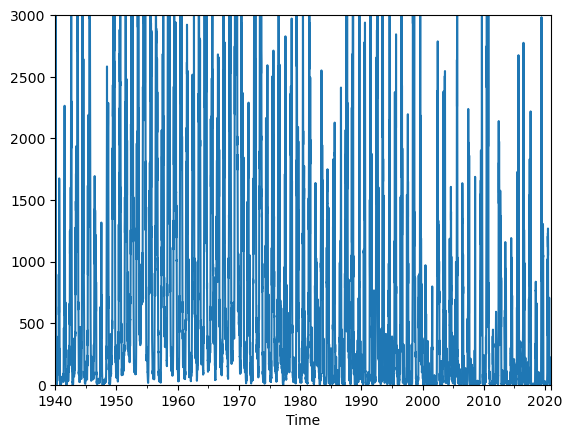

In [14]:
df["Chatly"].plot()
plt.ylim(0, 3000)

In [15]:
Amu_chatly = aral.River(df, q_col="Chatly", name="Amu Darya - Chatly")
Amu_kerki = aral.River(df, q_col="Kerki", name="Amu Darya - Kerki")
Syr_kaza = aral.River(df, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# Syr_kara = aral.River(df, q_col="Karaozek", name="Syr Darya - Karaozek")
Syr_tyumen = aral.River(df, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")

In [16]:
Amu_chatly_no_agri = aral.River(df_no_agri, q_col="Chatly", name="Amu Darya - Chatly")
Amu_kerki_no_agri = aral.River(df_no_agri, q_col="Kerki", name="Amu Darya - Kerki")
Syr_kaza_no_agri = aral.River(df_no_agri, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# Syr_kara_no_agri = aral.River(df_no_agri, q_col="Karaozek", name="Syr Darya - Karaozek")
Syr_tyumen_no_agri = aral.River(df_no_agri, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")

In [17]:
Amu_chatly_cmip = aral.River(df_cmip, q_col="Chatly", name="Amu Darya - Chatly")
Amu_kerki_cmip = aral.River(df_cmip, q_col="Kerki", name="Amu Darya - Kerki")
Syr_kaza_cmip = aral.River(df_cmip, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# Syr_kara_cmip = aral.River(df_cmip, q_col="Karaozek", name="Syr Darya - Karaozek")
Syr_tyumen_cmip = aral.River(df_cmip, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")

In [ ]:

Amu_kerki_cmip.plot_yearly(
    observations=nachtnebel["Amudarya_Q"],
    observation_label="Nachtnebel Amudarya_Q",
)

Amu_chatly_cmip.plot_yearly(
    observations=nachtnebel["Amudarya_Q"],
    observation_label="Nachtnebel Amudarya_Q",
)

Syr_kaza_cmip.plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

TypeError: River.plot_yearly() got an unexpected keyword argument 'observations'

In [19]:
# Build one combined dataframe indexed by date
df_i = df.copy()
df_cmip_i = df_cmip.copy()

df_i.index = pd.to_datetime(df_i.index)
df_cmip_i.index = pd.to_datetime(df_cmip_i.index)

df_combined = pd.concat(
    {"era5": df_i, "cmip": df_cmip_i},
    axis=1,
).sort_index()

print(f"df_combined shape: {df_combined.shape}")
print(f"period: {df_combined.index.min()} -> {df_combined.index.max()}")
df_combined.head()

df_combined shape: (33238, 12)
period: 1940-01-01 00:00:00 -> 2030-12-31 00:00:00


era5                                                     \
                Chatly   Kazalinsk       Kerki Tyumen-Aryk     Uch-Kurgan   
Time                                                                        
1940-01-01  278.454163  330.595245  580.939697  281.809113   43507.074219   
1940-01-02  364.476685  282.263641  826.298706  229.267044  148399.734375   
1940-01-03  394.875183  326.399445  814.482422  244.749969      48.759827   
1940-01-04  250.635559  288.364075  619.810669  251.554260      10.215573   
1940-01-05  181.749161  326.938324  641.950378  262.985687       7.434420   

                         cmip                                              
                  Garm Chatly Kazalinsk Kerki Tyumen-Aryk Uch-Kurgan Garm  
Time                                                                       
1940-01-01    3.268690    NaN       NaN   NaN         NaN        NaN  NaN  
1940-01-02    1.331893    NaN       NaN   NaN         NaN        NaN  NaN  
1940-01-03  106.029945    NaN       NaN   NaN         NaN        NaN  NaN  
1940-01-04    0.432104    NaN       NaN   NaN         NaN        NaN  NaN  
1940-01-05    0.418758    NaN       NaN   NaN         NaN        NaN  NaN

In [20]:
grdc_station_chatly = get_grdc_data(
    2817100, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)

In [21]:
grdc_station_chatly

<xarray.Dataset> Size: 199kB
Dimensions:              (time: 12418)
Coordinates:
  * time                 (time) datetime64[ns] 99kB 1940-01-02 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 99kB 494.0 494.0 470.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

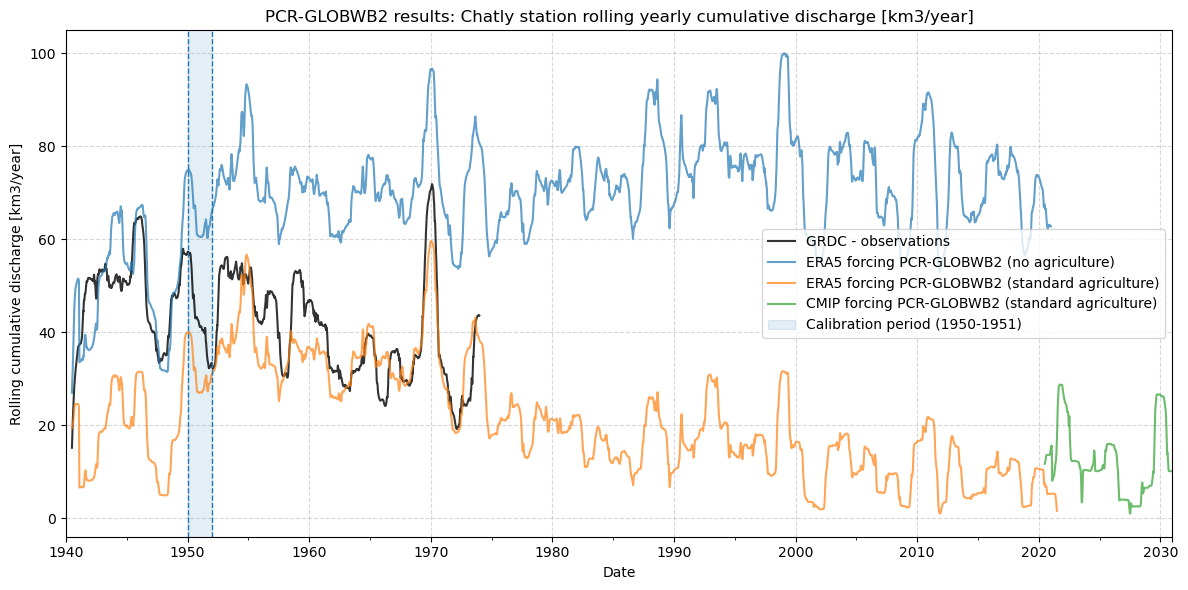

In [22]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day
grdc_station_chatly_roll_cum = (
    conversion_factor
    * grdc_station_chatly["streamflow"].rolling(time=window_days, min_periods=min_periods).sum().to_series()
)
chatly_era5_roll_cum = conversion_factor * df_combined[("era5", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
chatly_cmip_roll_cum = conversion_factor * df_combined[("cmip", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
chatly_no_agri_roll_cum = conversion_factor * df_no_agri["Chatly"].rolling(window=window_days, min_periods=min_periods).sum()

cal_start = pd.Timestamp("1950-01-01")
cal_end = pd.Timestamp("1951-12-31")

plt.figure(figsize=(12, 6))
grdc_station_chatly_roll_cum.plot(label="GRDC - observations", color="black", alpha=0.8)
chatly_no_agri_roll_cum.plot(label="ERA5 forcing PCR-GLOBWB2 (no agriculture)", color="tab:blue", alpha=0.7)
chatly_era5_roll_cum.plot(label="ERA5 forcing PCR-GLOBWB2 (standard agriculture)", color="tab:orange", alpha=0.7)
chatly_cmip_roll_cum.plot(label="CMIP forcing PCR-GLOBWB2 (standard agriculture)", color="tab:green", alpha=0.7)

plt.axvspan(cal_start, cal_end, color="tab:blue", alpha=0.12, label="Calibration period (1950-1951)")
plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)
plt.title("PCR-GLOBWB2 results: Chatly station rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc = "center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

In [87]:
importlib.reload(aral)

nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")


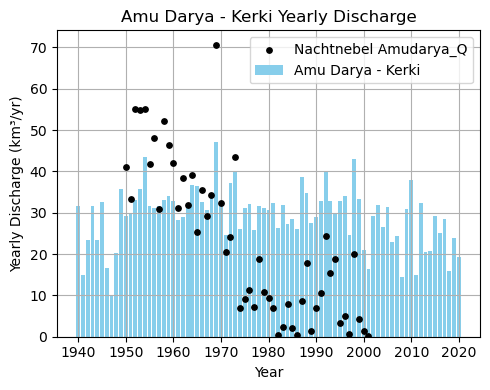

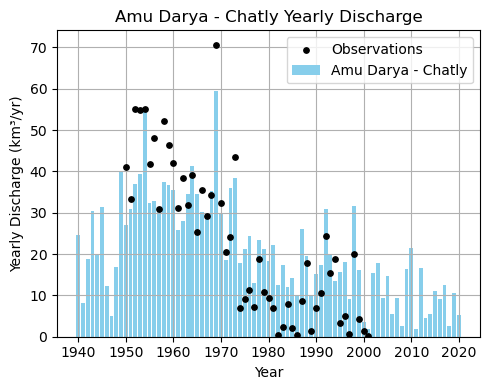

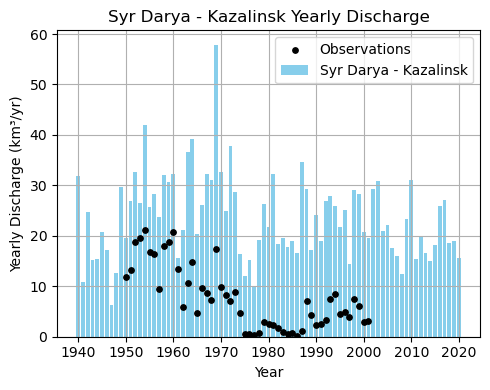

In [94]:
importlib.reload(aral)

Amu_chatly = aral.River(df, q_col="Chatly", name="Amu Darya - Chatly")
Amu_kerki = aral.River(df, q_col="Kerki", name="Amu Darya - Kerki")
Syr_kaza = aral.River(df, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# Syr_kara = aral.River(df, q_col="Karaozek", name="Syr Darya - Karaozek")
Syr_tyumen = aral.River(df, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")



fig1 = Amu_kerki.plot_yearly(
    return_fig=True,
    observations=nachtnebel["Amudarya_Q"],
    observation_label="Nachtnebel Amudarya_Q",
    )
fig2 = Amu_chatly.plot_yearly(
    return_fig=True,
    observations=nachtnebel["Amudarya_Q"],
    observation_label="Observations", 
    )

fig3 = Syr_kaza.plot_yearly(return_fig=True,
                            observations=nachtnebel["Syrdarya_Q"],
    observation_label="Observations",
    )
import os

os.makedirs("figures", exist_ok=True)
fig1.savefig("figures/Amu_kerki_yearly_discharge.pdf", bbox_inches="tight")
fig2.savefig("figures/Amu_chatly_yearly_discharge.pdf", bbox_inches="tight")
fig3.savefig("figures/Syr_kaza_yearly_discharge.pdf", bbox_inches="tight")

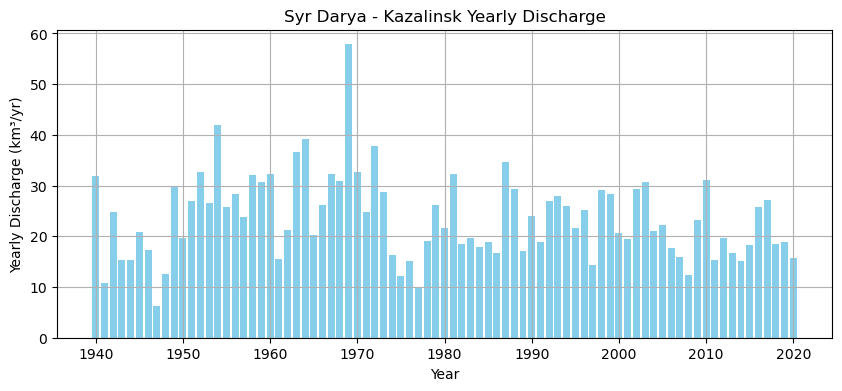

In [74]:
Syr_kaza.plot_yearly()

In [25]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model
df_aral = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[Amu_chatly, Syr_kaza],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
    tqdm_position=1,
)

Simulating Aral Sea volume balance:   0%|          | 0/25932 [00:00<?, ?it/s]

In [26]:
df_aral_no_agri = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[Amu_chatly_no_agri, Syr_kaza_no_agri],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
    tqdm_position=1,
)

Simulating Aral Sea volume balance:   0%|          | 0/25932 [00:00<?, ?it/s]

In [36]:
observation = aral.make_obs()

Found 1 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


[(         time  elevation_m
0  1950-01-01        52.82
1  1951-01-01        52.72
2  1952-01-01        52.70
3  1953-01-01        52.86
4  1954-01-01        53.12
5  1955-01-01        53.16
6  1956-01-01        53.22
7  1957-01-01        53.19
8  1958-01-01        53.16
9  1959-01-01        53.28
10 1960-01-01        53.40
11 1961-01-01        53.29
12 1962-01-01        52.97
13 1963-01-01        52.63
14 1964-01-01        52.49
15 1965-01-01        52.30
16 1966-01-01        51.87
17 1967-01-01        51.56
18 1968-01-01        51.23
19 1969-01-01        51.28
20 1970-01-01        51.41
21 1971-01-01        51.06
22 1972-01-01        50.55
23 1973-01-01        50.22
24 1974-01-01        49.86
25 1975-01-01        49.01
26 1976-01-01        48.27
27 1977-01-01        47.64
28 1978-01-01        47.05
29 1979-01-01        46.45
30 1980-01-01        45.75
31 1981-01-01        45.19
32 1982-01-01        44.39
33 1983-01-01        43.56
34 1984-01-01        42.76
35 1985-01-01        41.94

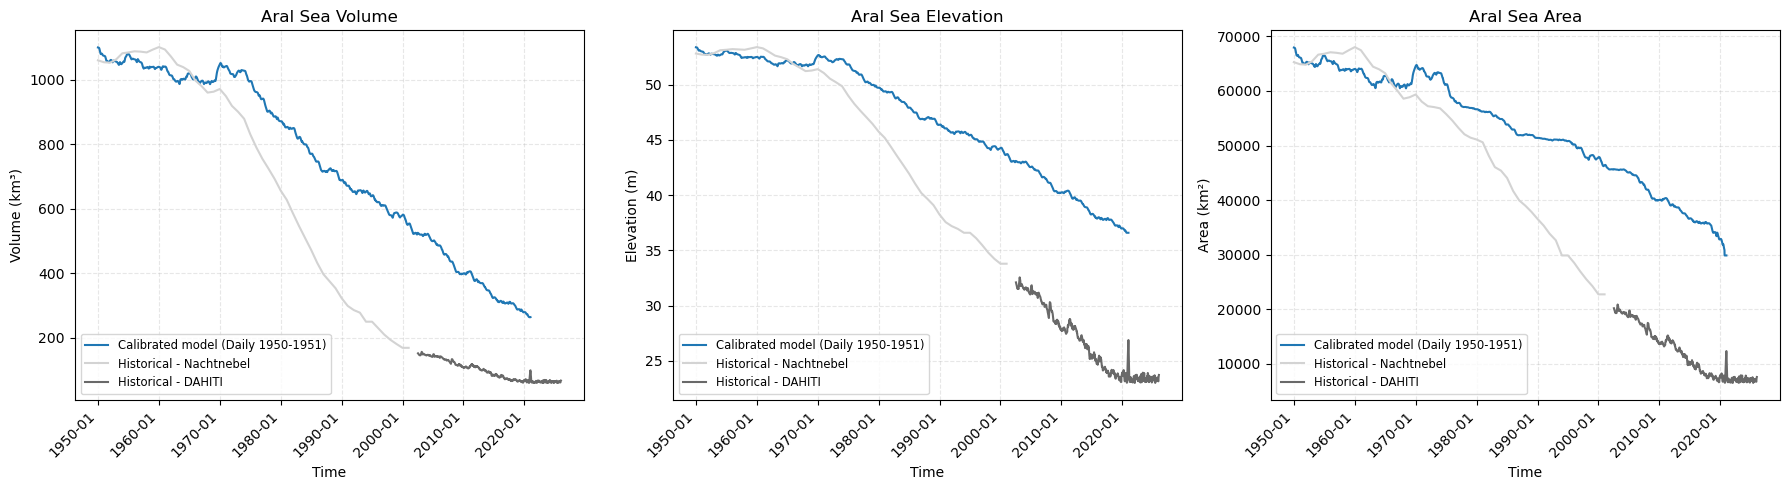

In [66]:
aral.plot_aral_results(df_aral,labels=["Calibrated model (Daily 1950-1951)"], observations=observation)

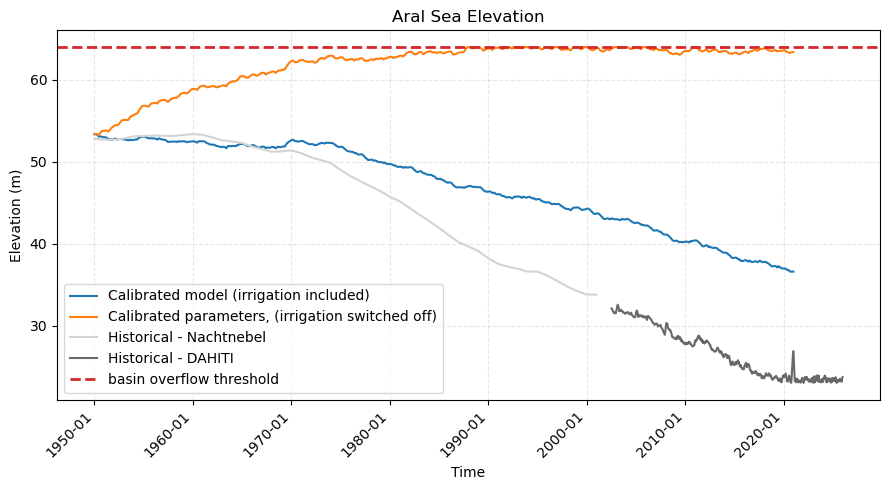

In [84]:
importlib.reload(aral)
aral.plot_aral_elevation(
    [df_aral, df_aral_no_agri],
    labels=[
        "Calibrated model (irrigation included)",
        "Calibrated parameters, (irrigation switched off)",
    ],
    observations=observation,
)

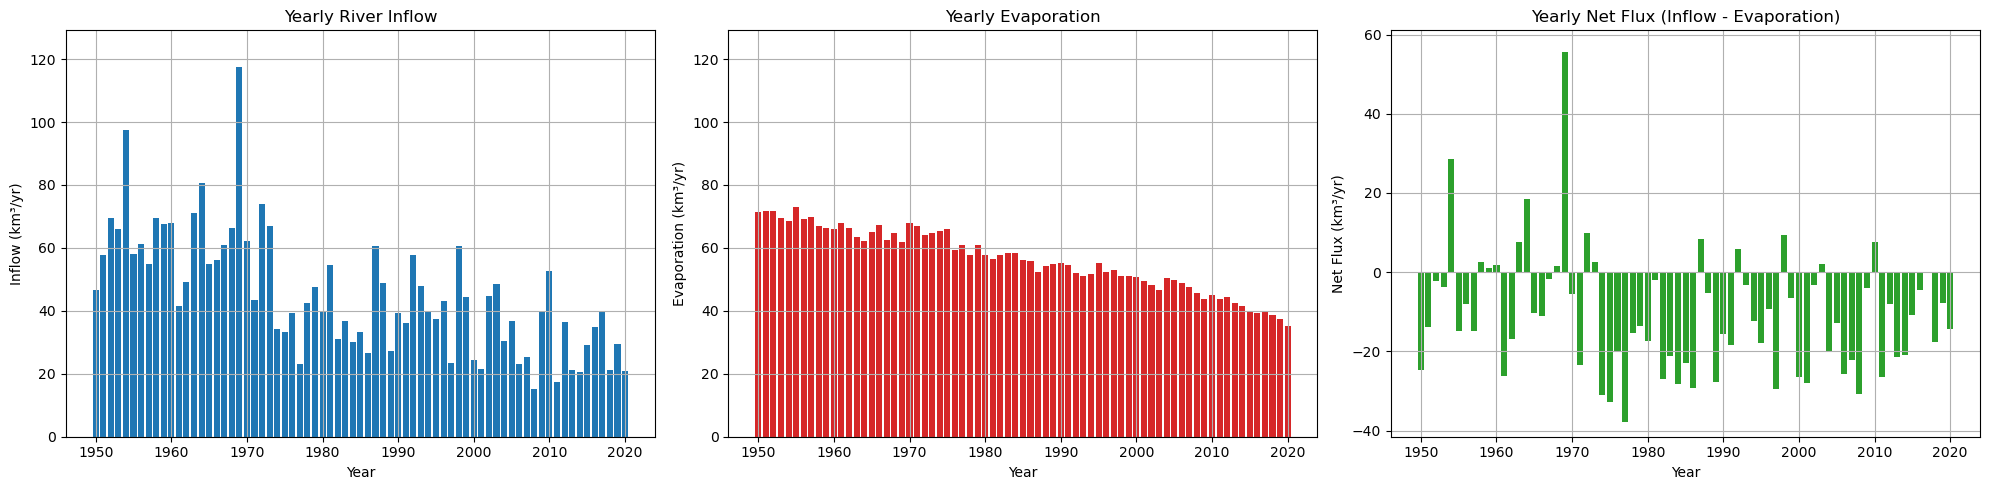

In [39]:
aral.plot_aral_fluxes(df_aral)